# Regresión Lineal — California Housing
**Dataset real de internet:** California Housing (censo 1990)

- `m = 20,640` muestras  
- `n = 12` features  
- **Prediccion:** `Price` (precio de vivienda en USD)

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

## 1. Cargar Dataset con Pandas
> Dataset: California Housing — descargable desde:
> `https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv`

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [ ]:
# Leer CSV con Pandas
#df = pd.read_csv('california_housing.csv')                    # local
df = pd.read_csv('/content/gdrive/MyDrive/Universida/IA/Dataset/california_housing.csv')  # Colab

m, n = df.shape[0], df.shape[1] - 1
print(f'Dataset: m={m} muestras, n={n} features')
df.describe().round(2)

Dataset: m=20640 muestras, n=12 features


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_num,rooms_per_household,bedrooms_per_room,population_per_household,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.0,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,-119.33,37.24,26.47,2322.46,464.29,1502.84,600.9,5.57,0.91,7.50,0.20,2.55,303204.63
std,2.90,2.71,14.69,1818.47,372.59,1430.74,570.1,2.81,1.00,11.03,0.03,0.38,121304.26
min,-124.35,32.54,1.00,98.00,18.00,57.00,19.0,0.83,0.00,0.05,0.15,2.00,15000.00
25%,-121.84,34.89,13.80,1132.00,222.00,641.00,252.0,3.53,0.00,2.03,0.17,2.22,209729.14
50%,-119.34,37.25,26.40,1834.00,361.00,1092.00,436.0,4.93,1.00,4.18,0.20,2.49,290513.92
75%,-116.82,39.57,39.20,2929.00,583.00,1873.25,744.0,6.96,1.00,8.65,0.22,2.85,398013.68
max,-114.31,41.95,52.00,24879.00,4769.00,23478.00,6082.0,15.00,3.00,255.21,0.25,3.86,500001.00


In [ ]:
#esta linea

In [ ]:
print("Tipos de datos de cada característica:")
display(df.dtypes)

print("\nInformación completa del DataFrame:")
df.info()

Tipos de datos de cada característica:


,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
ocean_proximity_num,int64
rooms_per_household,float64



Información completa del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20640 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   ocean_proximity_num       20640 non-null  int64  
 9   rooms_per_household       20640 non-null  float64
 10  bedrooms_per_room         20640 non-null  float64
 11  population_per_household  20640 non-null  float64
 12  Price                     20640 non-null  float64
dtypes: float64(12), int64(1)

In [ ]:
print("Recuento de valores nulos por característica:")
display(df.isnull().sum())

Recuento de valores nulos por característica:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
ocean_proximity_num,0
rooms_per_household,0


## 2. Preprocesamiento con Pandas

In [ ]:
df.dropna(inplace=True)                                          # eliminar nulos
df = df.clip(lower=df.quantile(0.01), upper=df.quantile(0.99), axis=1)  # recortar outliers

X_pd = df.drop(columns='Price').values
y_pd = df['Price'].values
m, n = X_pd.shape
print(f'Tras preprocesamiento: m={m}, n={n}')

Tras preprocesamiento: m=20640, n=12


## 3. Normalización + columna de unos (θ₀)

In [ ]:
mu, sigma = X_pd.mean(axis=0), X_pd.std(axis=0)
X_norm    = (X_pd - mu) / sigma
X_b       = np.hstack([np.ones((m, 1)), X_norm])   # agrega columna de unos
print(f'X_b shape: {X_b.shape}')

X_b shape: (20640, 13)


## 4. Función de Costo y Descenso por Gradiente

In [ ]:
def calcularCosto(X, y, theta):
    return (1 / (2 * len(y))) * np.sum(np.square(X @ theta - y))

def gradientDescent(X, y, theta, alpha, num_iters):
    theta, J_history = theta.copy(), []
    for _ in range(num_iters):
        theta    -= (alpha / len(y)) * (X @ theta - y) @ X
        J_history.append(calcularCosto(X, y, theta))
    return theta, J_history

## 5. Entrenamiento

In [ ]:
theta             = np.zeros(n + 1)
theta, J_history  = gradientDescent(X_b, y_pd, theta, alpha=0.1, num_iters=500)

print(f'Costo inicial : {J_history[0]:.2f}')
print(f'Costo final   : {J_history[-1]:.2f}')
print(f'Reducción     : {(1 - J_history[-1]/J_history[0])*100:.1f}%')

Costo inicial : 43197902802.18
Costo final   : 1216847326.51
Reducción     : 97.2%


## 6. Inferencia con Pandas

In [ ]:
# Tomar 3 muestras nuevas directamente desde el DataFrame
muestra      = df.drop(columns='Price').iloc[:3]
muestra_norm = (muestra.values - mu) / sigma
muestra_b    = np.hstack([np.ones((3, 1)), muestra_norm])
predicciones = muestra_b @ theta

print('Inferencia (3 viviendas):')
reales = df['Price'].iloc[:3].values
[print(f'  Casa {i+1} | Real: ${reales[i]:,.0f}  →  Predicho: ${p:,.0f}') for i, p in enumerate(predicciones)]

Inferencia (3 viviendas):
  Casa 1 | Real: $459,772  →  Predicho: $385,161
  Casa 2 | Real: $430,978  →  Predicho: $402,410
  Casa 3 | Real: $219,781  →  Predicho: $262,363


[None, None, None]

## 7. Gráficas

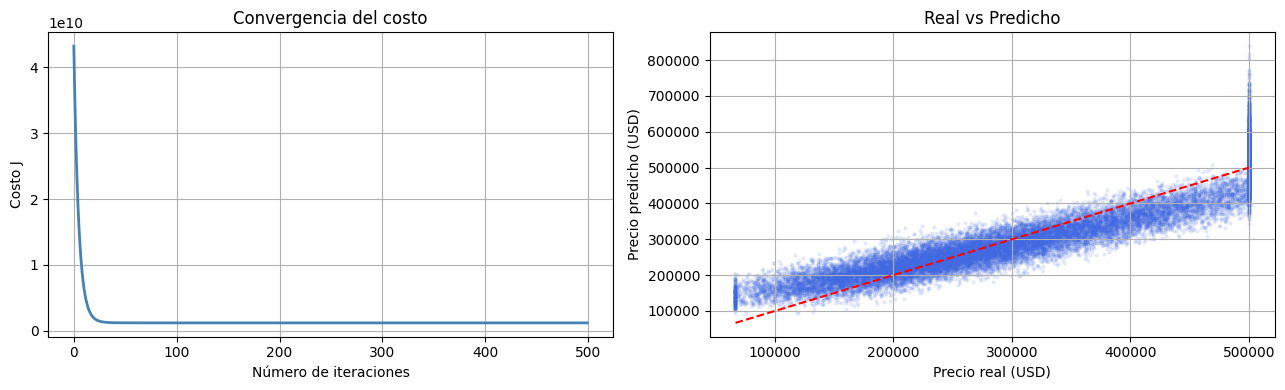

In [ ]:
fig, axes = pyplot.subplots(1, 2, figsize=(13, 4))

# Convergencia del costo
axes[0].plot(np.arange(len(J_history)), J_history, lw=2, color='steelblue')
axes[0].set(xlabel='Número de iteraciones', ylabel='Costo J', title='Convergencia del costo')
axes[0].grid(True)

# Real vs Predicho
y_pred_full = X_b @ theta
axes[1].scatter(y_pd, y_pred_full, alpha=0.1, s=4, color='royalblue')
lims = [y_pd.min(), y_pd.max()]
axes[1].plot(lims, lims, 'r--', lw=1.5)
axes[1].set(xlabel='Precio real (USD)', ylabel='Precio predicho (USD)', title='Real vs Predicho')
axes[1].grid(True)

pyplot.tight_layout()
pyplot.show()